# Descriptor ORB y Matching

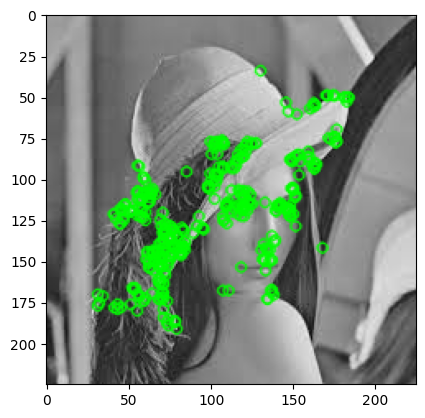

(<matplotlib.image.AxesImage at 0x20194a5bb10>, None)

In [10]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('img/lena.jpeg', cv2.IMREAD_GRAYSCALE)

# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints with ORB
kp = orb.detect(img,None)

# compute the descriptors with ORB
kp, des = orb.compute(img, kp)

# draw only keypoints location,not size and orientation
img2 = cv2.drawKeypoints(img, kp, None, color=(0,255,0), flags=0)
plt.imshow(img2), plt.show()

In [11]:
len(kp)

400

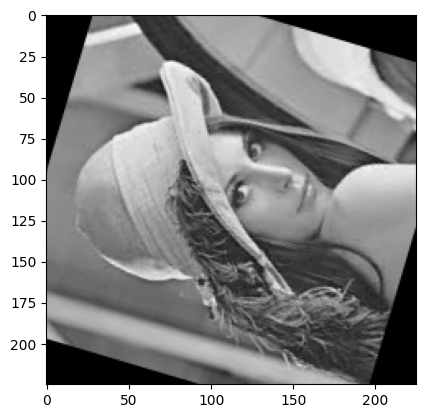

(<matplotlib.image.AxesImage at 0x20194af6850>, None)

In [12]:
h, w = img.shape
c = (h/2,w/2)
R = cv2.getRotationMatrix2D(c, 73.5, 1)
img_t = cv2.warpAffine(img, R, (w,h))
plt.imshow(img_t, cmap="gray"), plt.show()

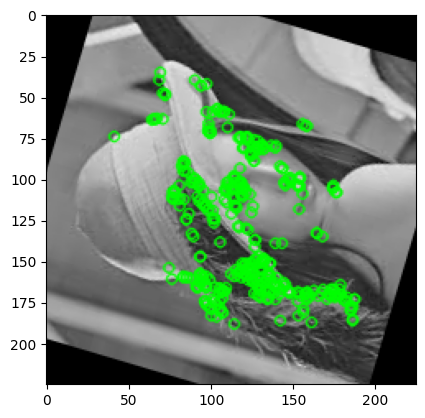

(<matplotlib.image.AxesImage at 0x20194b716d0>, None)

In [13]:
kp2 = orb.detect(img_t,None)
kp2, des2 = orb.compute(img_t, kp2)
img2_t = cv2.drawKeypoints(img_t, kp2, None, color=(0,255,0), flags=0)
plt.imshow(img2_t), plt.show()

In [14]:
def visualize_matches(img1, kp1, desc1, img2, kp2, desc2, n_matches=20):
    """Visualiza los mejores matches entre dos imágenes"""
    
    # Matching
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desc1, desc2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Tomar los mejores n_matches
    good_matches = matches[:n_matches]
    
    # Filtrar por distancia (opcional)
    max_distance = good_matches[-1].distance
    print(f"Distancia mínima: {good_matches[0].distance}")
    print(f"Distancia máxima: {max_distance}")
    
    # Dibujar matches
    result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    return (result, good_matches)

Distancia mínima: 6.0
Distancia máxima: 7.0


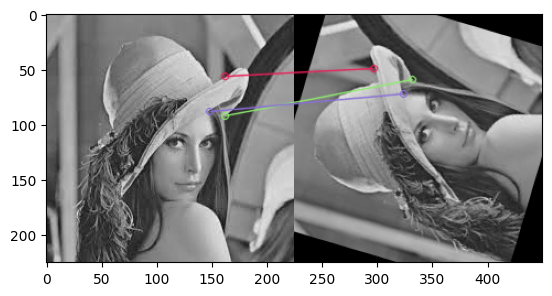

(<matplotlib.image.AxesImage at 0x20194c002d0>, None)

In [15]:
img_match, good_matches = visualize_matches(img, kp, des, img_t, kp2, des2, 3)
plt.imshow(img_match), plt.show()

In [16]:
good_matches = good_matches[:3]

p1 = np.array([kp[good_matches[i].queryIdx].pt for i in range(3)])
p2 = np.array([kp2[good_matches[i].trainIdx].pt for i in range(3)])

# 👉 AQUÍ VA LO NUEVO
p1 = np.float32(p1)
p2 = np.float32(p2)

M = cv2.getAffineTransform(p1, p2)

print("Matriz de transformación:\n", M)

h, w = img.shape
img_affine = cv2.warpAffine(img, M, (w, h))

Matriz de transformación:
 [[  0.29365079   0.97222222 -30.01587302]
 [ -1.00793651   0.27777778 196.73015873]]


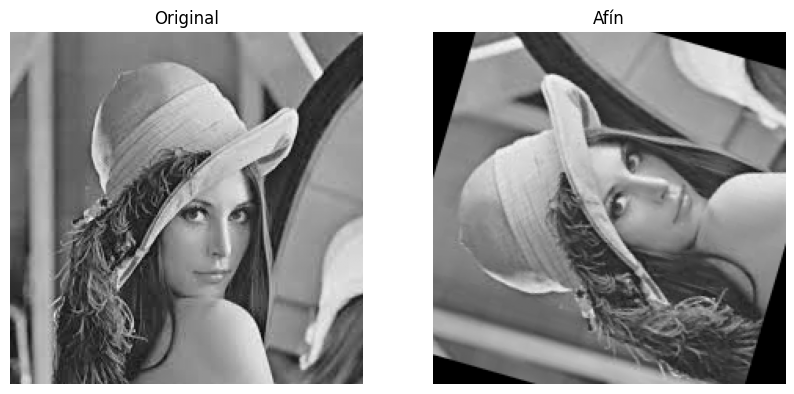

In [17]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Afín")
plt.imshow(img_affine, cmap="gray")
plt.axis("off")

plt.show()

In [18]:
p1

array([[162.,  56.],
       [162.,  92.],
       [148.,  88.]], dtype=float32)